In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [2]:

#C:\Users\bda\Desktop\261100660031\AML_LAB\Lab_5\Income_Data.csv
df = pd.read_csv(r"D:\AIML_MSIS\Applied Machine Learning\Lab_Assignment\LAB 5\Income_Data.csv")

In [3]:
df.head()

,Unnamed: 0,income,happiness
0,1,3.862647,2.314489
1,2,4.979381,3.433490
2,3,4.923957,4.599373
3,4,3.214372,2.791114
4,5,7.196409,5.596398


In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.isnull().sum()

Unnamed: 0    0
income        0
happiness     0
dtype: int64

In [6]:
x = df[["income"]]
x

,income
0,3.862647
1,4.979381
2,4.923957
3,3.214372
4,7.196409
...,...
493,5.249209
494,3.471799
495,6.087610
496,3.440847


In [7]:
y = df["happiness"]
y

0      2.314489
1      3.433490
2      4.599373
3      2.791114
4      5.596398
         ...   
493    4.568705
494    2.535002
495    4.397451
496    2.070664
497    3.710193
Name: happiness, Length: 498, dtype: float64

In [8]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 1/3, random_state = 42)

In [9]:
model = LinearRegression()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

In [10]:
print("Intercept : ", model.intercept_)
print("Slope : ", model.coef_[0])

Intercept :  0.21570555762000598
Slope :  0.7104017602319236


In [11]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

print("MAE       : ", mean_absolute_error(y_test, y_pred))
print("MSE       : ", mean_squared_error(y_test, y_pred))
print("RMSE      : ", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R-squared : ", r2_score(y_test, y_pred))

MAE       :  0.6147018074341307
MSE       :  0.5702802558684427
RMSE      :  0.7551690247013861
R-squared :  0.7282137737842489


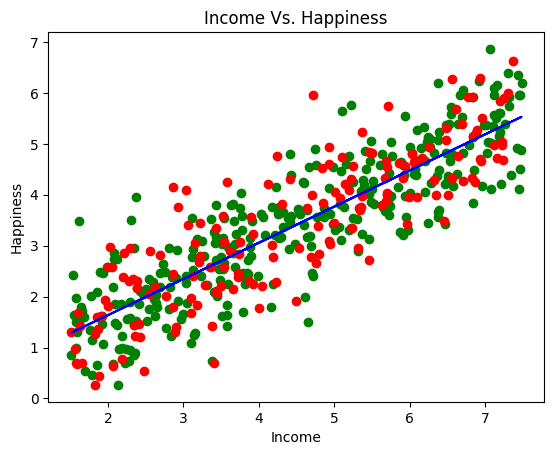

In [12]:
plt.scatter(x_train, y_train, color = 'green')
plt.scatter(x_test, y_test, color = 'red')
plt.plot(x_train, model.predict(x_train), color = 'blue')

plt.xlabel("Income")
plt.ylabel("Happiness")
plt.title("Income Vs. Happiness")
plt.show()


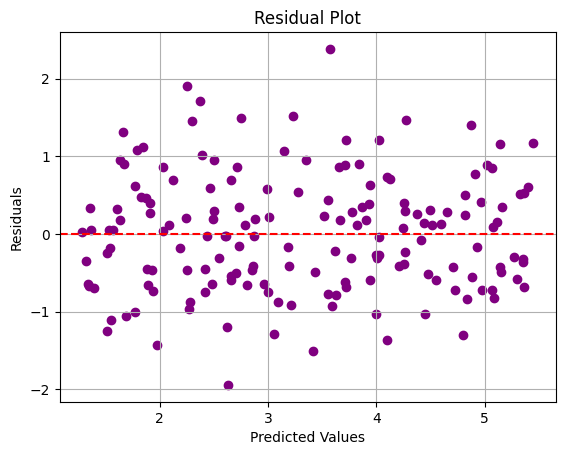

In [13]:
y_pred_test = model.predict(x_test)

residuals = y_test - y_pred_test

plt.scatter(y_pred_test, residuals, color = "purple")
plt.axhline(y = 0, color = "red", linestyle = "--")

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.grid(True)
plt.show()

K-FOLD

In [14]:
np.random.seed(42)
expanded_indices = np.random.choice(df.index, size=100, replace=True)

x = df.loc[expanded_indices, ["income"]].values

x = x + np.random.normal(0, 0.05, x.shape)

y = df.loc[expanded_indices, "happiness"].values
y = y + np.random.normal(0, 0.05, y.shape)



In [15]:
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import r2_score

k_values = [4, 5, 6]
test_sizes = [0.20, 0.25, 0.30]
results = []

for k in k_values:
    for test_size in test_sizes:
        x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=test_size, random_state=42)
        
        kf = KFold(n_splits=k, shuffle=True, random_state=42)
        fold_scores = []
        
        for train_idx, val_idx in kf.split(x_train):
            x_fold_train, x_fold_val = x_train[train_idx], x_train[val_idx]
            y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]
        
            fold_model = LinearRegression()
            fold_model.fit(x_fold_train, y_fold_train)
            
            y_fold_pred = fold_model.predict(x_fold_val)
            r2 = r2_score(y_fold_val, y_fold_pred)
            fold_scores.append(r2)
            
        results.append({
            "K (Folds)": k,
            "Test Size (%)": int(test_size * 100),
            "Fold Scores (R²)": [round(score, 4) for score in fold_scores],
            "Average R²": round(np.mean(fold_scores), 4)
        })


In [16]:
df_results = pd.DataFrame(results)
print("Results : ")
df_results


Results : 


,K (Folds),Test Size (%),Fold Scores (R²),Average R²
0,4,20,"[0.8268, 0.8396, 0.4315, 0.6078]",0.6764
1,4,25,"[0.8099, 0.8467, 0.6317, 0.6575]",0.7365
2,4,30,"[0.7874, 0.3321, 0.7925, 0.7771]",0.6723
3,5,20,"[0.8373, 0.9068, 0.7796, 0.0512, 0.7792]",0.6708
4,5,25,"[0.8134, 0.8581, 0.8216, 0.6198, 0.5438]",0.7313
5,5,30,"[0.8296, 0.3077, 0.6898, 0.7656, 0.7868]",0.6759
6,6,20,"[0.855, 0.8525, 0.8141, 0.4373, 0.3968, 0.6863]",0.6737
7,6,25,"[0.8176, 0.8409, 0.8389, 0.6642, 0.5533, 0.534]",0.7082
8,6,30,"[0.83, -0.0913, 0.6393, 0.7736, 0.8647, 0.7401]",0.6261


In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

final_model = LinearRegression()
final_model.fit(x_train, y_train)
y_pred = final_model.predict(x_test)

print("MAE       : ", mean_absolute_error(y_test, y_pred))
print("MSE       : ", mean_squared_error(y_test, y_pred))
print("RMSE      : ", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R-squared : ", r2_score(y_test, y_pred))

MAE       :  0.4097576308118694
MSE       :  0.2388281916272973
RMSE      :  0.48870051322594016
R-squared :  0.8804540386135191


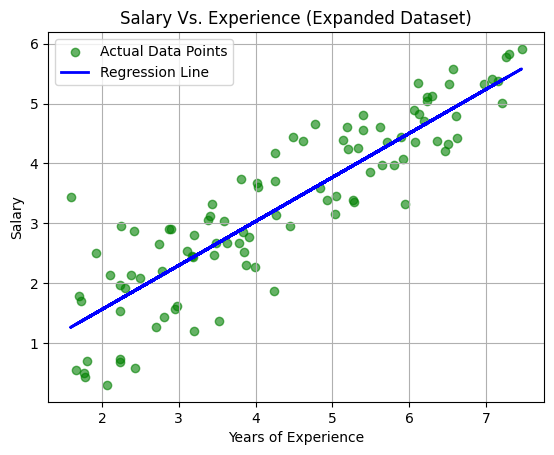

In [18]:
y_plot_line = final_model.predict(x)
plt.scatter(x, y, color="green", alpha=0.6, label="Actual Data Points")
plt.plot(x, y_plot_line, color="blue", linewidth=2, label="Regression Line")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Salary Vs. Experience (Expanded Dataset)")
plt.grid(True)
plt.legend()
plt.show()

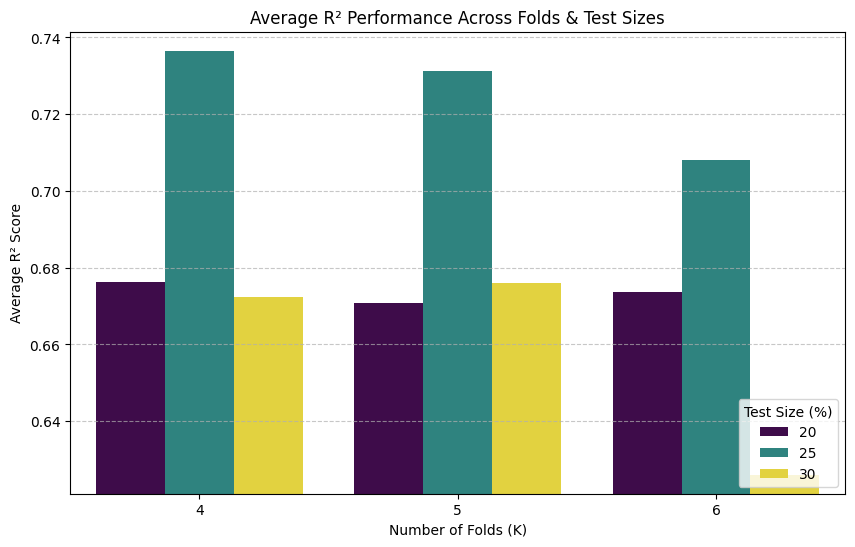

In [19]:
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(data=df_results, x = "K (Folds)", y="Average R²", hue="Test Size (%)", palette="viridis")

plt.title("Average R² Performance Across Folds & Test Sizes")
plt.xlabel("Number of Folds (K)")
plt.ylabel("Average R² Score")
plt.grid(axis='y', linestyle='--', alpha=0.7)

min_score = df_results["Average R²"].min()
max_score = df_results["Average R²"].max()
plt.ylim(min_score - 0.005, max_score + 0.005)

plt.legend(title="Test Size (%)", loc="lower right")
plt.show()
